# PAMAP2 Physical Activity Monitoring Exploratory Data Analysis

## Project Context

This notebook explores the PAMAP2 Physical Activity Monitoring dataset as the wearable-sensor component of the **Integrated Intelligent Health Monitoring and Clinical Decision Support System**.

The goals are to:

- inspect the raw subject files and sensor structure;
- verify available participants and activity labels;
- examine missing values;
- evaluate class balance across activities;
- inspect heart-rate and inertial sensor behavior;
- identify a practical subset of sensor channels for modeling;
- define a sequence-window strategy for the later LSTM activity-recognition model.

The PAMAP2 dataset is analyzed independently from the Diabetes 130-US Hospitals dataset because the two datasets represent different populations. Their model outputs will be integrated later at the application and agent level rather than through direct patient-level joining.


## Setup

Import the libraries used for data loading, inspection, analysis, and visualization.


In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42


## Locate the Project and PAMAP2 Data

The notebook expects the extracted PAMAP2 subject files to be stored under:

`data/raw/pamap2/`

The code searches recursively for `.dat` files so it works whether the extracted archive contains an additional `Protocol` directory or the subject files were copied directly into `data/raw/pamap2/`.


In [32]:
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the healthcare_capstone project root."
    )

PAMAP2_DIR = PROJECT_ROOT / "data" / "raw" / "pamap2"

if not PAMAP2_DIR.exists():
    raise FileNotFoundError(
        f"PAMAP2 directory not found at: {PAMAP2_DIR}"
    )

subject_files = sorted(PAMAP2_DIR.rglob("subject*.dat"))

print("Project root:", PROJECT_ROOT)
print("PAMAP2 directory:", PAMAP2_DIR)
print("Subject files found:", len(subject_files))

for path in subject_files:
    print(path.relative_to(PAMAP2_DIR))


Project root: c:\Private\UDACITY\CAPSTONE\INTEGRATED_AI_SYSTEM\healthcare_capstone
PAMAP2 directory: c:\Private\UDACITY\CAPSTONE\INTEGRATED_AI_SYSTEM\healthcare_capstone\data\raw\pamap2
Subject files found: 9
subject101.dat
subject102.dat
subject103.dat
subject104.dat
subject105.dat
subject106.dat
subject107.dat
subject108.dat
subject109.dat


## PAMAP2 Column Structure

Each row in the PAMAP2 protocol files contains a timestamp, activity identifier, heart-rate measurement, and measurements from inertial measurement units located on the hand, chest, and ankle.

This notebook assigns explicit column names so the raw whitespace-separated files can be loaded into pandas dataframes.


In [33]:
IMU_FEATURES = [
    "temperature",
    "acc16_x", "acc16_y", "acc16_z",
    "acc6_x", "acc6_y", "acc6_z",
    "gyro_x", "gyro_y", "gyro_z",
    "mag_x", "mag_y", "mag_z",
    "orientation_1", "orientation_2", "orientation_3", "orientation_4",
]

COLUMN_NAMES = [
    "timestamp",
    "activity_id",
    "heart_rate",
]

for location in ["hand", "chest", "ankle"]:
    COLUMN_NAMES.extend(
        [f"{location}_{feature}" for feature in IMU_FEATURES]
    )

print("Expected number of columns:", len(COLUMN_NAMES))
print(COLUMN_NAMES[:15])


Expected number of columns: 54
['timestamp', 'activity_id', 'heart_rate', 'hand_temperature', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y']


## Load the Subject Files

Each protocol file is loaded and assigned a `subject_id` derived from its filename. The subject dataframes are then concatenated into a single exploratory dataframe.


In [34]:
if not subject_files:
    raise FileNotFoundError(
        "No subject*.dat files were found. "
        "Check that the PAMAP2 archive has been extracted under data/raw/pamap2/."
    )

subject_frames = []

for file_path in subject_files:
    subject_id = file_path.stem.replace("subject", "")

    subject_df = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
        names=COLUMN_NAMES,
        na_values="NaN",
    )

    subject_df["subject_id"] = subject_id
    subject_frames.append(subject_df)

pamap2 = pd.concat(
    subject_frames,
    ignore_index=True,
)

print("Combined dataset shape:", pamap2.shape)
pamap2.head()


Combined dataset shape: (2872533, 55)


,timestamp,activity_id,heart_rate,hand_temperature,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,hand_mag_x,hand_mag_y,hand_mag_z,hand_orientation_1,hand_orientation_2,hand_orientation_3,hand_orientation_4,chest_temperature,chest_acc16_x,chest_acc16_y,chest_acc16_z,chest_acc6_x,chest_acc6_y,chest_acc6_z,chest_gyro_x,chest_gyro_y,chest_gyro_z,chest_mag_x,chest_mag_y,chest_mag_z,chest_orientation_1,chest_orientation_2,chest_orientation_3,chest_orientation_4,ankle_temperature,ankle_acc16_x,ankle_acc16_y,ankle_acc16_z,ankle_acc6_x,ankle_acc6_y,ankle_acc6_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_orientation_1,ankle_orientation_2,ankle_orientation_3,ankle_orientation_4,subject_id
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,-0.092217,0.056812,-0.015845,14.6806,-69.2128,-5.58905,1.0,0.0,0.0,0.0,31.8125,0.238080,9.80003,-1.68896,0.265304,9.81549,-1.41344,-0.005065,-0.006781,-0.005663,0.471960,-51.0499,43.2903,1.0,0.0,0.0,0.0,30.3125,9.65918,-1.65569,-0.099797,9.64689,-1.55576,0.310404,0.008300,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0,101
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,-0.024413,0.047759,0.006474,14.8991,-69.2224,-5.82311,1.0,0.0,0.0,0.0,31.8125,0.319530,9.61282,-1.49328,0.234939,9.78539,-1.42846,0.013685,0.001486,-0.041522,1.016900,-50.3966,43.1768,1.0,0.0,0.0,0.0,30.3125,9.69370,-1.57902,-0.215687,9.61670,-1.61630,0.280488,-0.006577,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0,101
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,-0.057976,0.032574,-0.006988,14.2420,-69.5197,-5.12442,1.0,0.0,0.0,0.0,31.8125,0.235593,9.72421,-1.76621,0.173850,9.72528,-1.51894,-0.039923,0.034056,-0.002113,0.383136,-51.8336,43.7782,1.0,0.0,0.0,0.0,30.3125,9.58944,-1.73276,0.092914,9.63173,-1.58605,0.280311,0.003014,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0,101
3,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277,-0.002352,0.032810,-0.003747,14.8908,-69.5439,-6.17367,1.0,0.0,0.0,0.0,31.8125,0.388697,9.53572,-1.72410,0.157969,9.64994,-1.57952,0.007513,-0.010498,-0.020684,0.315400,-49.8144,43.1670,1.0,0.0,0.0,0.0,30.3125,9.58814,-1.77040,0.054545,9.63197,-1.63135,0.340997,0.003175,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1.0,0.0,0.0,0.0,101
4,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295,0.012269,0.018305,-0.053325,15.5612,-68.8196,-6.28927,1.0,0.0,0.0,0.0,31.8125,0.315800,9.49908,-1.60914,0.233506,9.57411,-1.44418,-0.003822,-0.011217,-0.025975,-0.297733,-51.8097,43.6453,1.0,0.0,0.0,0.0,30.3125,9.69771,-1.65625,-0.060809,9.64699,-1.64647,0.340965,0.012698,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1.0,0.0,0.0,0.0,101


## Initial Dataset Inspection

Inspect dataframe structure, data types, the number of participants, and duplicate rows before further analysis.


In [35]:
print(f"Rows: {pamap2.shape[0]:,}")
print(f"Columns: {pamap2.shape[1]}")
print("Unique subjects:", pamap2["subject_id"].nunique())
print("Activity IDs:", sorted(pamap2["activity_id"].dropna().unique()))

pamap2.info()


Rows: 2,872,533
Columns: 55
Unique subjects: 9
Activity IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]
<class 'pandas.DataFrame'>
RangeIndex: 2872533 entries, 0 to 2872532
Data columns (total 55 columns):
 #   Column               Dtype  
---  ------               -----  
 0   timestamp            float64
 1   activity_id          int64  
 2   heart_rate           float64
 3   hand_temperature     float64
 4   hand_acc16_x         float64
 5   hand_acc16_y         float64
 6   hand_acc16_z         float64
 7   hand_acc6_x          float64
 8   hand_acc6_y          float64
 9   hand_acc6_z          float64
 10  hand_gyro_x          float64
 11  hand_gyro_y          float64
 12  hand_gyro_z          float64
 13  hand_mag_x           float64
 14  hand_mag_y           float64
 15  hand_mag_z           float64
 16  hand_orientation_1   float64
 17  hand_orient

In [36]:
duplicate_count = pamap2.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print(
    f"Duplicate percentage: "
    f"{duplicate_count / len(pamap2) * 100:.4f}%"
)


Duplicate rows: 0
Duplicate percentage: 0.0000%


## Activity Labels

Map numeric activity identifiers to readable activity names. Activity ID `0` represents transition or unlabeled periods and will be inspected separately before deciding whether to exclude it from model training.


In [37]:
ACTIVITY_LABELS = {
    0: "transient",
    1: "lying",
    2: "sitting",
    3: "standing",
    4: "walking",
    5: "running",
    6: "cycling",
    7: "nordic_walking",
    9: "watching_tv",
    10: "computer_work",
    11: "car_driving",
    12: "ascending_stairs",
    13: "descending_stairs",
    16: "vacuum_cleaning",
    17: "ironing",
    18: "folding_laundry",
    19: "house_cleaning",
    20: "playing_soccer",
    24: "rope_jumping",
}

pamap2["activity"] = (
    pamap2["activity_id"]
    .map(ACTIVITY_LABELS)
    .fillna("unknown")
)

pamap2[["activity_id", "activity"]].drop_duplicates().sort_values(
    "activity_id"
)


,activity_id,activity
0,0,transient
2928,1,lying
30115,2,sitting
53595,3,standing
223759,4,walking
312742,5,running
283096,6,cycling
253175,7,nordic_walking
154281,12,ascending_stairs
173396,13,descending_stairs


## Participant Distribution

Review the number of observations recorded for each participant. This is important because the later LSTM evaluation should separate participants across training and testing where possible, rather than randomly splitting windows from the same participant into both sets.


In [38]:
subject_counts = (
    pamap2["subject_id"]
    .value_counts()
    .sort_index()
)

subject_counts


subject_id
101    376417
102    447000
103    252833
104    329576
105    374783
106    361817
107    313599
108    408031
109      8477
Name: count, dtype: int64

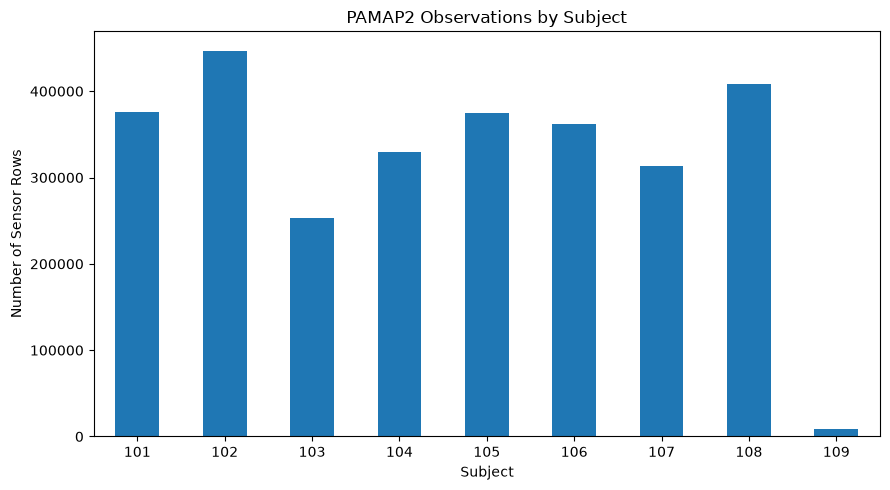

In [39]:
plt.figure(figsize=(9, 5))
subject_counts.plot(kind="bar")

plt.title("PAMAP2 Observations by Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Sensor Rows")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


## Activity Distribution

Class balance matters for activity recognition because strongly underrepresented classes may receive poor recall even when overall accuracy appears high.

Both raw activity IDs and readable labels are examined below.


In [40]:
activity_counts = (
    pamap2["activity"]
    .value_counts()
)

activity_percentages = (
    pamap2["activity"]
    .value_counts(normalize=True)
    * 100
)

activity_distribution = pd.DataFrame({
    "count": activity_counts,
    "percentage": activity_percentages,
})

activity_distribution


,count,percentage
activity,,
transient,929661,32.363806
walking,238761,8.311863
ironing,238690,8.309391
lying,192523,6.702203
standing,189931,6.611969
nordic_walking,188107,6.548471
sitting,185188,6.446854
vacuum_cleaning,175353,6.104473
cycling,164600,5.730134


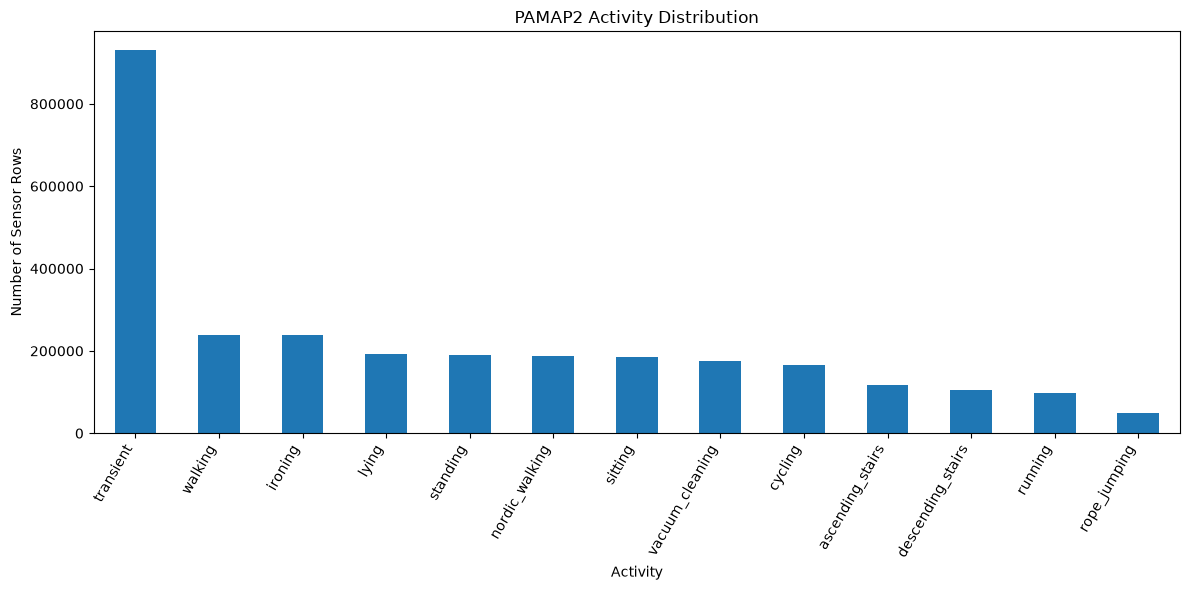

In [41]:
plt.figure(figsize=(12, 6))

activity_counts.sort_values(ascending=False).plot(kind="bar")

plt.title("PAMAP2 Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Sensor Rows")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()


## Transient and Unlabeled Periods

Activity ID `0` represents transition or unlabeled periods rather than one of the target activities. The proportion of these observations is measured before creating the modeling subset.


In [42]:
transient_count = int(
    (pamap2["activity_id"] == 0).sum()
)

transient_percent = (
    transient_count / len(pamap2) * 100
)

print("Transient/unlabeled rows:", transient_count)
print(f"Transient/unlabeled percentage: {transient_percent:.2f}%")


Transient/unlabeled rows: 929661
Transient/unlabeled percentage: 32.36%


## Create an Exploratory Modeling Subset

For activity-recognition analysis, remove transient activity ID `0`. The full raw dataframe remains unchanged.


In [43]:
pamap2_model = pamap2.loc[
    pamap2["activity_id"] != 0
].copy()

print("Rows before filtering:", len(pamap2))
print("Rows after filtering:", len(pamap2_model))
print(
    "Modeled activities:",
    pamap2_model["activity"].nunique()
)


Rows before filtering: 2872533
Rows after filtering: 1942872
Modeled activities: 12


## Missing-Value Analysis

Wearable recordings may contain missing heart-rate or sensor measurements. Missingness is quantified before selecting features and defining the preprocessing strategy.


In [44]:
missing_report = pd.DataFrame({
    "missing_count": pamap2_model.isna().sum(),
})

missing_report["missing_percent"] = (
    missing_report["missing_count"]
    / len(pamap2_model)
    * 100
)

missing_report = missing_report[
    missing_report["missing_count"] > 0
].sort_values(
    "missing_percent",
    ascending=False
)

missing_report.head(30)


,missing_count,missing_percent
heart_rate,1765464,90.868776
hand_temperature,11124,0.572554
hand_acc16_x,11124,0.572554
hand_acc16_y,11124,0.572554
hand_acc16_z,11124,0.572554
hand_acc6_x,11124,0.572554
hand_acc6_y,11124,0.572554
hand_acc6_z,11124,0.572554
hand_gyro_x,11124,0.572554
hand_gyro_y,11124,0.572554


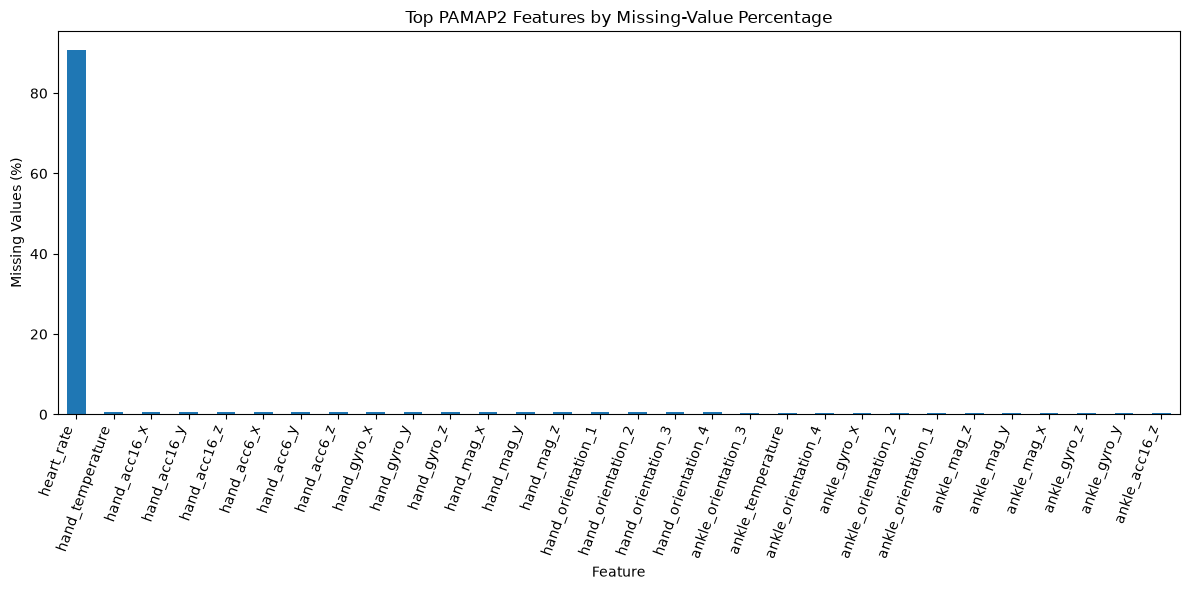

In [45]:
plt.figure(figsize=(12, 6))

missing_report["missing_percent"].head(30).plot(
    kind="bar"
)

plt.title("Top PAMAP2 Features by Missing-Value Percentage")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=70, ha="right")

plt.tight_layout()
plt.show()


## Heart-Rate Analysis

Heart rate is a useful physiological feature but may contain missing values because it is sampled differently from the inertial signals.

The overall distribution and average heart rate by activity are examined below.


In [46]:
pamap2_model["heart_rate"].describe()


count    177408.000000
mean        107.468502
std          26.977609
min          57.000000
25%          86.000000
50%         104.000000
75%         124.000000
max         202.000000
Name: heart_rate, dtype: float64

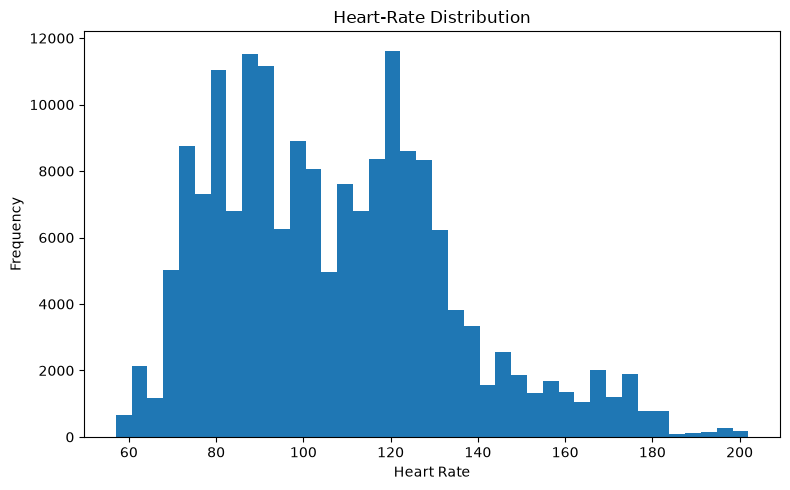

In [47]:
plt.figure(figsize=(8, 5))

plt.hist(
    pamap2_model["heart_rate"].dropna(),
    bins=40,
)

plt.title("Heart-Rate Distribution")
plt.xlabel("Heart Rate")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [48]:
heart_rate_by_activity = (
    pamap2_model
    .groupby("activity")["heart_rate"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean", ascending=False)
)

heart_rate_by_activity


,mean,median,std,count
activity,,,,
rope_jumping,161.981391,166.0,21.666430,4514
running,156.595814,166.0,22.792422,8887
ascending_stairs,129.523485,130.0,20.895509,10709
descending_stairs,129.154175,129.0,22.956029,9593
cycling,124.879952,125.0,8.608116,15044
nordic_walking,123.828701,125.0,10.982627,17198
walking,112.789865,115.0,9.529361,21786
vacuum_cleaning,104.198091,101.0,13.513390,16028
ironing,90.069591,89.0,8.936990,21770


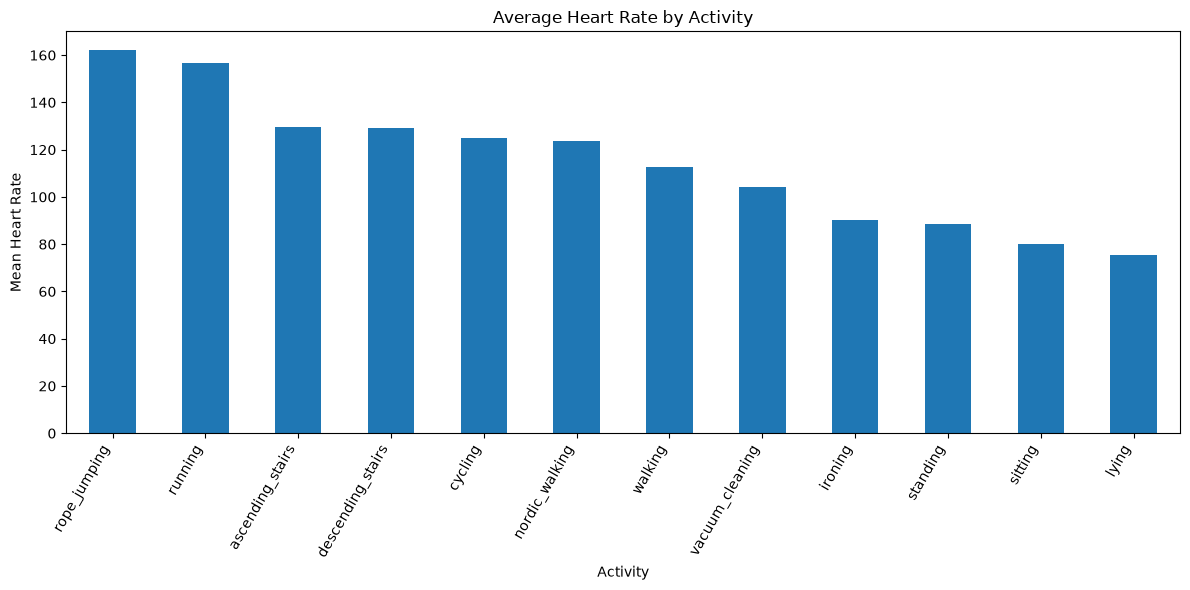

In [49]:
plt.figure(figsize=(12, 6))

heart_rate_by_activity["mean"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Average Heart Rate by Activity")
plt.xlabel("Activity")
plt.ylabel("Mean Heart Rate")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()


## Inertial Sensor Inspection

The full PAMAP2 dataset contains a large number of sensor channels. To keep the capstone manageable, the activity-recognition model will begin with a selected subset of interpretable channels rather than every available measurement.

The candidate subset includes:

- heart rate;
- 3-axis accelerometer measurements from the hand, chest, and ankle;
- 3-axis gyroscope measurements from the hand, chest, and ankle.

This provides physiological context plus movement information from all three body locations while keeping the sequence dimensionality practical.


In [50]:
SELECTED_SENSOR_FEATURES = [
    "heart_rate",

    "hand_acc16_x",
    "hand_acc16_y",
    "hand_acc16_z",
    "hand_gyro_x",
    "hand_gyro_y",
    "hand_gyro_z",

    "chest_acc16_x",
    "chest_acc16_y",
    "chest_acc16_z",
    "chest_gyro_x",
    "chest_gyro_y",
    "chest_gyro_z",

    "ankle_acc16_x",
    "ankle_acc16_y",
    "ankle_acc16_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
]

print("Selected sensor features:", len(SELECTED_SENSOR_FEATURES))

pamap2_model[
    SELECTED_SENSOR_FEATURES
].describe().T


Selected sensor features: 19


,count,mean,std,min,25%,50%,75%,max
heart_rate,177408.0,107.468502,26.977609,57.00000,86.000000,104.000000,124.000000,202.00000
hand_acc16_x,1931748.0,-4.938311,6.231142,-145.36700,-8.955800,-5.426670,-0.943004,62.85960
hand_acc16_y,1931748.0,3.580308,6.887907,-104.30100,1.048068,3.523155,6.454320,155.69900
hand_acc16_z,1931748.0,3.609347,3.960176,-101.45200,1.161655,3.441330,6.538525,157.76000
hand_gyro_x,1931748.0,0.000647,1.328472,-28.13540,-0.376868,-0.006076,0.332370,26.41580
hand_gyro_y,1931748.0,0.039901,0.954215,-17.84950,-0.222411,0.005905,0.265597,23.07790
hand_gyro_z,1931748.0,-0.002220,1.595544,-14.26470,-0.379899,-0.005582,0.364851,14.33840
chest_acc16_x,1940452.0,0.333198,1.742714,-39.20340,-0.512879,0.439875,1.125780,27.52230
chest_acc16_y,1940452.0,8.152818,4.888182,-46.92460,5.948675,9.197610,9.776470,153.58200
chest_acc16_z,1940452.0,-1.451662,4.763873,-80.16680,-4.209243,-1.463550,0.520910,44.06930


## Missingness in Selected Features

Inspect only the features proposed for the LSTM. This directly informs the later interpolation and imputation strategy.


In [51]:
selected_missingness = pd.DataFrame({
    "missing_count": pamap2_model[
        SELECTED_SENSOR_FEATURES
    ].isna().sum()
})

selected_missingness["missing_percent"] = (
    selected_missingness["missing_count"]
    / len(pamap2_model)
    * 100
)

selected_missingness.sort_values(
    "missing_percent",
    ascending=False
)


,missing_count,missing_percent
heart_rate,1765464,90.868776
hand_acc16_x,11124,0.572554
hand_acc16_y,11124,0.572554
hand_acc16_z,11124,0.572554
hand_gyro_x,11124,0.572554
hand_gyro_y,11124,0.572554
hand_gyro_z,11124,0.572554
ankle_acc16_z,8507,0.437857
ankle_gyro_x,8507,0.437857
ankle_acc16_x,8507,0.437857


## Example Sensor Signal

Plot one accelerometer channel for a limited portion of a single subject. This confirms that the data behave as a time series rather than as independent tabular observations.


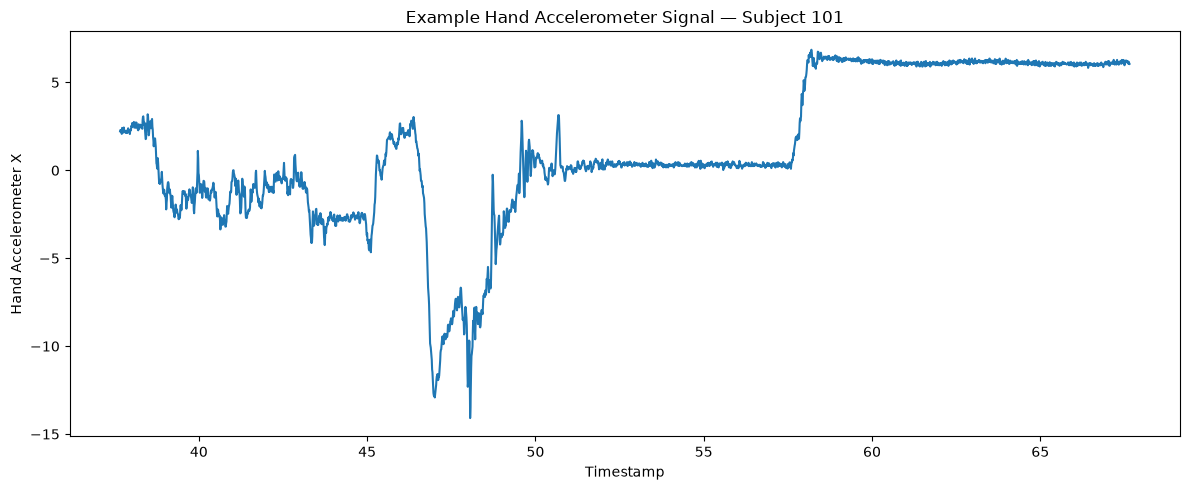

In [52]:
example_subject = pamap2_model["subject_id"].iloc[0]

example_signal = (
    pamap2_model.loc[
        pamap2_model["subject_id"] == example_subject,
        ["timestamp", "hand_acc16_x", "activity"]
    ]
    .head(3000)
)

plt.figure(figsize=(12, 5))

plt.plot(
    example_signal["timestamp"],
    example_signal["hand_acc16_x"],
)

plt.title(
    f"Example Hand Accelerometer Signal — Subject {example_subject}"
)
plt.xlabel("Timestamp")
plt.ylabel("Hand Accelerometer X")

plt.tight_layout()
plt.show()


## Activity-Level Sensor Summary

Compare average absolute acceleration by activity as a simple descriptive measure of movement intensity. This is exploratory and is not used as the final activity-recognition algorithm.


In [53]:
pamap2_model["hand_acc16_magnitude"] = np.sqrt(
    pamap2_model["hand_acc16_x"] ** 2
    + pamap2_model["hand_acc16_y"] ** 2
    + pamap2_model["hand_acc16_z"] ** 2
)

activity_acceleration = (
    pamap2_model
    .groupby("activity")["hand_acc16_magnitude"]
    .mean()
    .sort_values(ascending=False)
)

activity_acceleration


activity
running              20.159978
rope_jumping         13.779343
walking              11.252547
nordic_walking       10.979514
vacuum_cleaning      10.763168
cycling              10.677880
ascending_stairs     10.670235
descending_stairs    10.341614
ironing              10.018181
standing              9.783719
sitting               9.760423
lying                 9.728160
Name: hand_acc16_magnitude, dtype: float64

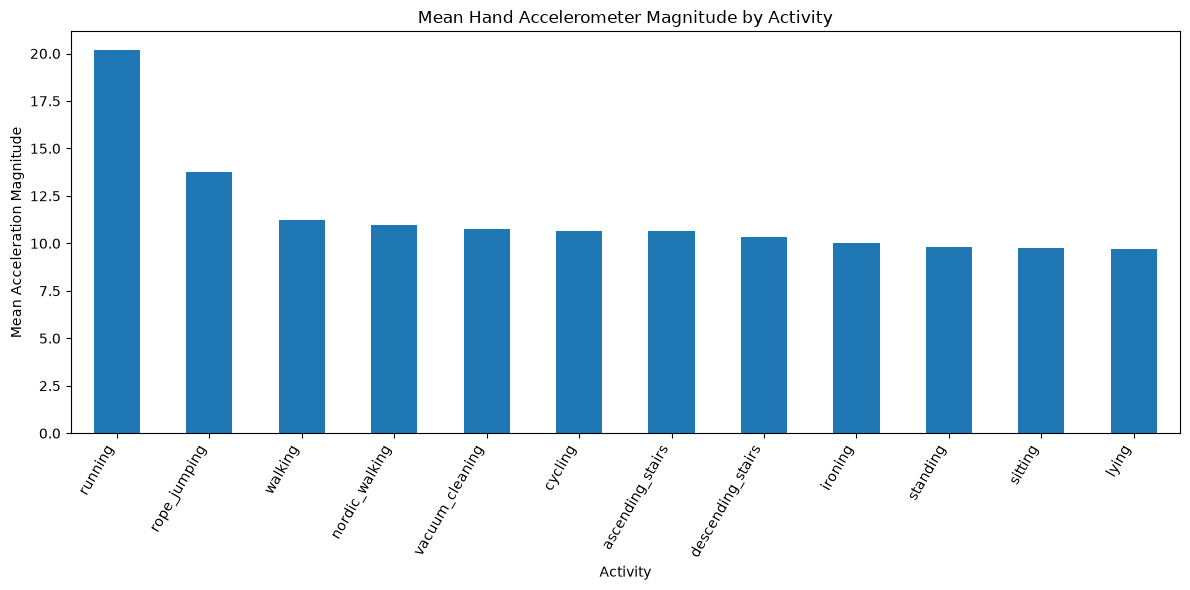

In [54]:
plt.figure(figsize=(12, 6))

activity_acceleration.plot(kind="bar")

plt.title("Mean Hand Accelerometer Magnitude by Activity")
plt.xlabel("Activity")
plt.ylabel("Mean Acceleration Magnitude")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()


## Participant Coverage by Activity

Some activities may not be represented equally across participants. This table counts how many unique subjects contributed observations to each activity.


In [55]:
subject_activity_coverage = (
    pamap2_model
    .groupby("activity")["subject_id"]
    .nunique()
    .sort_values(ascending=False)
    .to_frame("subjects")
)

subject_activity_coverage


,subjects
activity,
ascending_stairs,8
descending_stairs,8
ironing,8
lying,8
walking,8
vacuum_cleaning,8
standing,8
sitting,8
cycling,7


## Sequence-Window Design

The later LSTM will not classify individual sensor rows. Instead, continuous recordings will be divided into fixed-length windows.

A practical starting design is:

- window length: **100 time steps**;
- overlap: **50%**;
- label: majority activity within the window;
- windows should not cross participant boundaries;
- windows should not cross clearly different activity segments where avoidable.

The exact configuration will be implemented and validated in `src/preprocessing/pamap2.py`.


In [56]:
WINDOW_SIZE = 100
WINDOW_STEP = 50

print("Planned window size:", WINDOW_SIZE)
print("Planned step size:", WINDOW_STEP)
print(
    f"Planned overlap: "
    f"{(1 - WINDOW_STEP / WINDOW_SIZE) * 100:.0f}%"
)


Planned window size: 100
Planned step size: 50
Planned overlap: 50%


## Approximate Window Availability

Estimate the upper-bound number of windows that could be generated from each subject if continuous rows were windowed directly. The production preprocessing step will be more careful because windows should respect activity segments.


In [57]:
estimated_windows = {}

for subject_id, subject_df in pamap2_model.groupby("subject_id"):
    n_rows = len(subject_df)

    if n_rows >= WINDOW_SIZE:
        n_windows = (
            (n_rows - WINDOW_SIZE) // WINDOW_STEP
            + 1
        )
    else:
        n_windows = 0

    estimated_windows[subject_id] = n_windows

estimated_windows = pd.Series(
    estimated_windows,
    name="estimated_windows"
)

estimated_windows


101    4998
102    5265
103    3485
104    4627
105    5447
106    5000
107    4654
108    5241
109     126
Name: estimated_windows, dtype: int64

## Candidate Activity Set

The full dataset contains many activities, but a capstone model does not need to maximize the number of classes.

A manageable approach is to begin with activities that are sufficiently represented across subjects and reflect distinct movement patterns. The table below provides the evidence needed to make that decision after running the notebook.


In [58]:
activity_modeling_report = pd.DataFrame({
    "rows": pamap2_model["activity"].value_counts(),
    "subjects": pamap2_model.groupby("activity")[
        "subject_id"
    ].nunique(),
})

activity_modeling_report["row_percent"] = (
    activity_modeling_report["rows"]
    / len(pamap2_model)
    * 100
)

activity_modeling_report.sort_values(
    "rows",
    ascending=False
)


,rows,subjects,row_percent
activity,,,
walking,238761,8,12.289075
ironing,238690,8,12.285421
lying,192523,8,9.909196
standing,189931,8,9.775786
nordic_walking,188107,7,9.681904
sitting,185188,8,9.531662
vacuum_cleaning,175353,8,9.025453
cycling,164600,7,8.471994
ascending_stairs,117216,8,6.033130


## Data Quality Summary

Create a compact summary of the wearable dataset for use in later documentation and system evaluation.


In [59]:
summary = {
    "raw_rows": int(len(pamap2)),
    "modeled_rows": int(len(pamap2_model)),
    "columns": int(pamap2.shape[1]),
    "subjects": int(pamap2["subject_id"].nunique()),
    "raw_activity_labels": int(
        pamap2["activity_id"].nunique()
    ),
    "modeled_activity_labels": int(
        pamap2_model["activity_id"].nunique()
    ),
    "selected_sensor_features": int(
        len(SELECTED_SENSOR_FEATURES)
    ),
    "transient_rows_removed": int(
        transient_count
    ),
    "selected_feature_missing_values": int(
        pamap2_model[
            SELECTED_SENSOR_FEATURES
        ].isna().sum().sum()
    ),
}

summary


{'raw_rows': 2872533,
 'modeled_rows': 1942872,
 'columns': 56,
 'subjects': 9,
 'raw_activity_labels': 13,
 'modeled_activity_labels': 12,
 'selected_sensor_features': 19,
 'transient_rows_removed': 929661,
 'selected_feature_missing_values': 1897770}

## Exploratory Analysis Summary

The PAMAP2 dataset provides multivariate physiological and inertial sensor measurements collected across multiple participants and physical activities.

The exploratory analysis is designed to establish several modeling decisions:

- **Sequence structure:** the sensor readings form continuous time series and should be modeled as windows rather than independent rows.
- **Participant separation:** subjects must be considered during train/test design to reduce leakage from person-specific movement patterns.
- **Transient observations:** activity ID `0` represents transition or unlabeled periods and should be excluded from the supervised target set.
- **Missing sensor values:** selected channels require an explicit interpolation or imputation strategy before LSTM training.
- **Class balance:** activity frequencies and participant coverage should be considered when choosing the final modeling classes and evaluation metrics.
- **Feature scope:** a focused subset of heart-rate, accelerometer, and gyroscope channels provides a practical balance between physiological context, movement information, and computational complexity.
- **Windowing:** fixed-length overlapping windows will convert the raw sensor stream into LSTM training examples.

The actual outputs from this notebook should be used to refine the final feature list, activity set, and window parameters before they are implemented in `src/preprocessing/pamap2.py`.


## Save Exploratory Reports

Save small summary tables for later reference. The sequence dataset is intentionally not created here; reusable window generation and sensor preprocessing belong in `src/preprocessing/pamap2.py`.


In [60]:
OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "pamap2"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

activity_distribution.to_csv(
    OUTPUT_DIR / "eda_activity_distribution.csv"
)

missing_report.to_csv(
    OUTPUT_DIR / "eda_missing_values.csv"
)

selected_missingness.to_csv(
    OUTPUT_DIR / "eda_selected_feature_missingness.csv"
)

activity_modeling_report.to_csv(
    OUTPUT_DIR / "eda_activity_modeling_report.csv"
)

pd.DataFrame([summary]).to_csv(
    OUTPUT_DIR / "eda_dataset_summary.csv",
    index=False,
)

print("PAMAP2 EDA reports saved to:", OUTPUT_DIR)


PAMAP2 EDA reports saved to: c:\Private\UDACITY\CAPSTONE\INTEGRATED_AI_SYSTEM\healthcare_capstone\data\processed\pamap2
